## Cleaning Data

In [4]:
import re
import pandas as pd
import matplotlib.pyplot as plt

all_meteorites = pd.read_csv("Meteorite_Landings.csv")
all_meteorites = all_meteorites.dropna()

# 1 = stony, 2 = iron, 3 = stony-iron
def match_class(type_str):
    if "Lodranite" in type_str or "lodranite" in type_str:
        return 3
    if "Achondrite" in type_str:
        return 1
    if "Angrite" in type_str:
        return 1
    if "Acapulcoite" in type_str:
        return 1
    if "Brachinite" in type_str:
        return 1
    if "Lunar" in type_str:
        return 1
    if "Martian" in type_str:
        return 1
    if "Chondrite" in type_str:
        return 1
    if "Aubrite" in type_str:
        return 1
    if "Eucrite" in type_str:
        return 1
    if "Iron" in type_str or "iron" in type_str:
        return 2
    if "Stone" in type_str:
        return 1
    if "OC" in type_str:
        return 1
    if "Ureilite" in type_str:
        return 1
    if "Winonaite" in type_str:
        return 1
    if "Pallasite" in type_str:
        return 3
    if "Mesosiderite" in type_str:
        return 3
    if "Howardite" in type_str:
        return 1
    if "Diogenite" in type_str:
        return 1
    if "LL" in type_str:
        return 1
    r_class = re.compile("R[^A-Za-z]")
    if r_class.match(type_str):
        return 1
    l_class = re.compile("L[^A-Za-z]")
    if l_class.match(type_str):
        return 1
    h_class = re.compile("H[^A-Za-z]")
    if h_class.match(type_str):
        return 1
    e_class = re.compile("E[^A-Za-z]")
    if e_class.match(type_str):
        return 1
    el_class = re.compile("EL[^A-Za-z]")
    if el_class.match(type_str):
        return 1
    c_num_class = re.compile("C\\d")
    if c_num_class.match(type_str):
        return 1
    cx_class = re.compile("C[A-Z]")
    if cx_class.match(type_str):
        return 1
    eh_class = re.compile("EH[^A-Za-z]")
    if eh_class.match(type_str):
        return 1
    if "K" == type_str or "K3" == type_str:
        return 1
    if (type_str == "C" or type_str == "E" or
        type_str == "EH" or type_str == "H" or
        type_str == "L" or type_str == "R"):
        return 1
    if type_str == "Enst achon-ung":
        return 1
    if type_str == "Fusion crust":
        return 1

type_list = []
for index in range(len(all_meteorites["recclass"])):
    type_str = all_meteorites["recclass"].iloc[index]
    type = match_class(type_str)
    if type is not None:
        type_list.append(type)

all_meteorites['Class Number'] = type_list

## Relative feature importance to determining location

/Users/quinnhelfand/Documents/GitHub/School/ISCI-396/.venv/lib/python3.13/site-packages/sklearn/base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/Users/quinnhelfand/Documents/GitHub/School/ISCI-396/.venv/lib/python3.13/site-packages/sklearn/base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


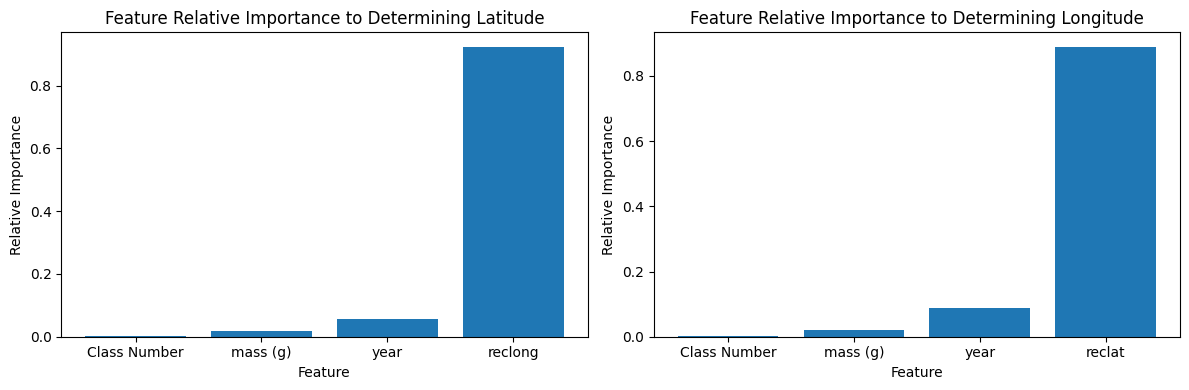

In [5]:
from sklearn.ensemble import RandomForestRegressor
fig, axs = plt.subplots(ncols=2, figsize=(12, 4))

ax_index = 0
def plot_relative_importance(X, y, label):
    global ax_index
    rf = RandomForestRegressor().fit(X, y)
    axs[ax_index].bar(X.keys(), rf.feature_importances_)
    axs[ax_index].set_xlabel('Feature')
    axs[ax_index].set_ylabel('Relative Importance')
    axs[ax_index].title.set_text(f"Feature Relative Importance to Determining {label}")
    ax_index += 1

X = all_meteorites[["Class Number", "mass (g)", "year", "reclong"]]
y = all_meteorites[["reclat"]]
plot_relative_importance(X, y, "Latitude")

X = all_meteorites[["Class Number", "mass (g)", "year", "reclat"]]
y = all_meteorites[["reclong"]]
plot_relative_importance(X, y, "Longitude")

plt.tight_layout()
plt.savefig("./relative-importance.png", format='png')
plt.show()

## Shapley values to estimate feature importance

/Users/quinnhelfand/Documents/GitHub/School/ISCI-396/.venv/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:1771: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Users/quinnhelfand/Documents/GitHub/School/ISCI-396/.venv/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:1771: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


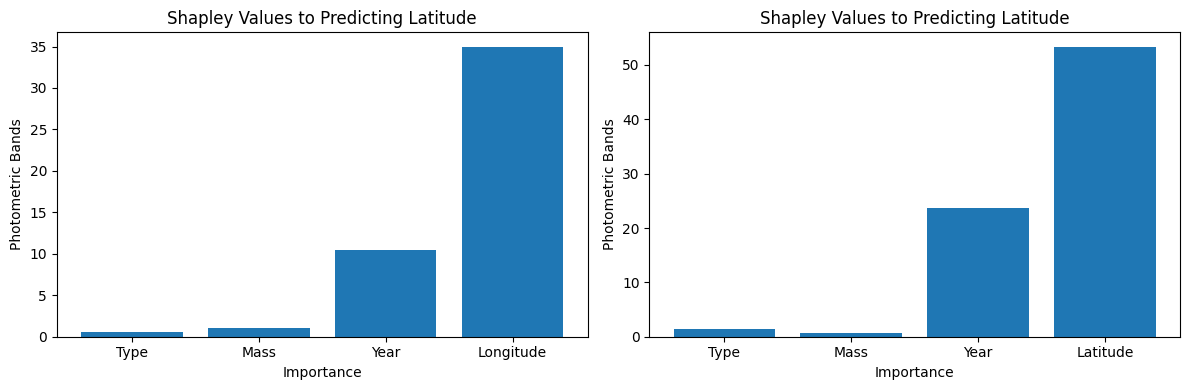

In [6]:
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor

fig, axs = plt.subplots(ncols=2, figsize=(12, 4))

def compute_shapley_values(X_target, X_bkg, model, n_mc=100):
    """Compute approximate shapley sampling values.

    Parameters
    ----------
    X_target : numpy.ndarray
        Target samples for which to compute Shapley values.
    X_bkg : numpy.ndarray
        Samples used as background in the Monte-Carlo simulation.
    model : object
        Model that has a `predict_proba` function for which we compute the
        Shapley values.
    n : n_mc
        Number of Monte-Carlo simulation. One Monte-Carlo simulations includes
        one random realization of the background and the order for each of the
        target samples.

    Returns
    -------
    shap : numpy.ndarray
        Shapley values. Has the same shape as ``X_target.``

    """
    n_samples, n_feat = X_target.shape
    shap = np.zeros((n_samples, n_feat))

    for k in range(n_mc):
        X = X_bkg[np.random.choice(len(X_bkg), size=len(X_target))]
        perm = np.random.permutation(n_feat)
        pred_old = model.predict(X)
        for feature in perm:
            X[:, feature] = X_target[:, feature]
            pred_new = model.predict(X)
            shap[:, feature] += (pred_new - pred_old) / n_mc
            pred_old = pred_new

    return shap

ax_index = 0
def plot_shapley_importance(X, y, label, headers):
    global ax_index

    X_scaled = StandardScaler().fit_transform(X)
    model = MLPRegressor(max_iter=1000, hidden_layer_sizes=(100, 100, 100)).fit(X_scaled, y)
    shap = compute_shapley_values(X_scaled, X_scaled, model)
    shap = np.mean(np.absolute(shap), axis=0)

    axs[ax_index].bar(headers, shap)
    axs[ax_index].set_ylabel('Photometric Bands')
    axs[ax_index].set_xlabel('Importance')
    axs[ax_index].title.set_text(f'Shapley Values to Predicting {label}')
    ax_index += 1

headers = ["Type", "Mass", "Year", "Longitude"]
X = all_meteorites[["Class Number", "mass (g)", "year", "reclong"]]
y = all_meteorites[["reclat"]]
plot_shapley_importance(X, y, "Latitude", headers)

headers = ["Type", "Mass", "Year", "Latitude"]
X = all_meteorites[["Class Number", "mass (g)", "year", "reclat"]]
y = all_meteorites[["reclong"]]
plot_shapley_importance(X, y, "Latitude", headers)

plt.tight_layout()
plt.savefig("./shapley-values.png", format='png')
plt.show()

## Gradient boosting to predict meteorite location

Latitude


,early_stopping,max_iter,max_depth,learning_rate,mean_test_score,rank_test_score,std_test_score
5,True,250,6,0.1,0.965281,1,0.003349
10,True,100,6,0.2,0.964826,2,0.002860
11,True,250,6,0.2,0.964767,3,0.003100
3,True,250,5,0.1,0.964642,4,0.003099
9,True,250,5,0.2,0.964575,5,0.003478
8,True,100,5,0.2,0.964521,6,0.003400
4,True,100,6,0.1,0.963850,7,0.003262
2,True,100,5,0.1,0.963228,8,0.003067
1,True,250,4,0.1,0.962979,9,0.003098
6,True,100,4,0.2,0.962828,10,0.003009


Longitude


,early_stopping,max_iter,max_depth,learning_rate,mean_test_score,rank_test_score,std_test_score
10,True,100,6,0.2,0.934793,1,0.003937
5,True,250,6,0.1,0.933759,2,0.004209
11,True,250,6,0.2,0.933555,3,0.004565
4,True,100,6,0.1,0.933493,4,0.004150
9,True,250,5,0.2,0.933067,5,0.004445
3,True,250,5,0.1,0.932786,6,0.004801
2,True,100,5,0.1,0.932320,7,0.004235
8,True,100,5,0.2,0.931948,8,0.004458
7,True,250,4,0.2,0.931670,9,0.004828
1,True,250,4,0.1,0.931041,10,0.004773


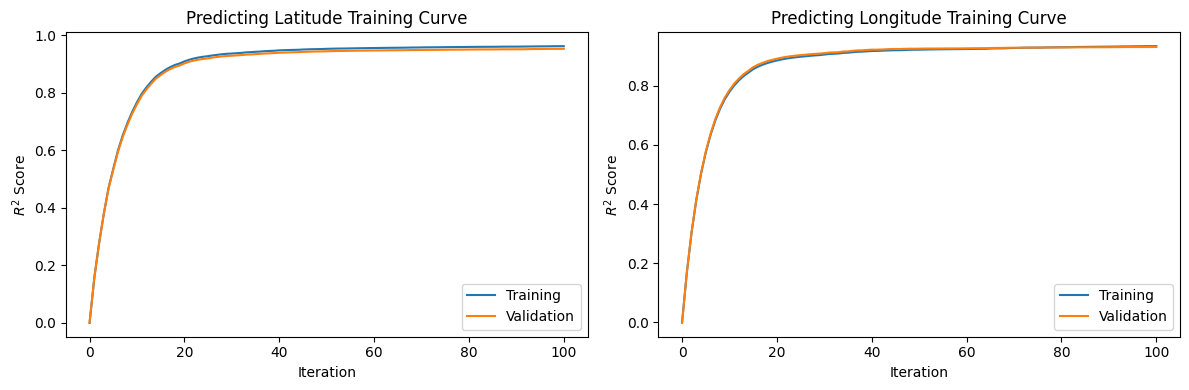

In [7]:
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.model_selection import GridSearchCV, KFold
import numpy as np

fig, axs = plt.subplots(ncols=2, figsize=(12, 4))

ax_index = 0
def make_training_plot(X, y, label):
    global ax_index

    gb = HistGradientBoostingRegressor()
    kfold = KFold(10, shuffle=True, random_state=0)
    param_grid = dict(early_stopping = [True],
                      max_iter = [100, 250],
                      max_depth = range(4, 7),
                      learning_rate = np.linspace(0.1, 0.2, 2))
    model = GridSearchCV(gb, param_grid= param_grid, cv = kfold, scoring='r2', return_train_score=True, n_jobs=-1).fit(X, y)

    df = pd.DataFrame(model.cv_results_)
    results = df.rename(columns={f'param_{param}' : param for param in param_grid.keys()})
    results = results[[param for param in param_grid.keys()] + ['mean_test_score', 'rank_test_score', 'std_test_score']]
    results = results.sort_values(by='rank_test_score')
    print(label)
    display(results)

    kwargs = df['params'][np.argmax(results['mean_test_score'] * results['early_stopping'])]
    gb = HistGradientBoostingRegressor(**kwargs).fit(X, y)

    axs[ax_index].title.set_text(f'Predicting {label} Training Curve')
    axs[ax_index].set_xlabel('Iteration')
    axs[ax_index].set_ylabel(r'$R^2$ Score')
    axs[ax_index].plot(1 - (-2 * gb.train_score_) / np.var(y), label='Training')
    axs[ax_index].plot(1 - (-2 * gb.validation_score_) / np.var(y), label='Validation')
    axs[ax_index].legend(loc='best')

    ax_index += 1

X = all_meteorites[["Class Number", "mass (g)", "year", "reclong"]]
y = np.ravel(all_meteorites[["reclat"]])
make_training_plot(X, y, "Latitude")

X = all_meteorites[["Class Number", "mass (g)", "year", "reclat"]]
y = np.ravel(all_meteorites[["reclong"]])
make_training_plot(X, y, "Longitude")

plt.tight_layout()
plt.savefig("./prediction-gradient-boosting.png", format='png')
plt.show()

## Gaussian mixture to classify by type

/Users/quinnhelfand/Documents/GitHub/School/ISCI-396/.venv/lib/python3.13/site-packages/sklearn/mixture/_base.py:275: ConvergenceWarning: Best performing initialization did not converge. Try different init parameters, or increase max_iter, tol, or check for degenerate data.
  warnings.warn(
/Users/quinnhelfand/Documents/GitHub/School/ISCI-396/.venv/lib/python3.13/site-packages/sklearn/mixture/_base.py:275: ConvergenceWarning: Best performing initialization did not converge. Try different init parameters, or increase max_iter, tol, or check for degenerate data.
  warnings.warn(
/Users/quinnhelfand/Documents/GitHub/School/ISCI-396/.venv/lib/python3.13/site-packages/sklearn/mixture/_base.py:275: ConvergenceWarning: Best performing initialization did not converge. Try different init parameters, or increase max_iter, tol, or check for degenerate data.
  warnings.warn(
/Users/quinnhelfand/Documents/GitHub/School/ISCI-396/.venv/lib/python3.13/site-packages/sklearn/mixture/_base.py:275: Conver

Best number of components: 48


/Users/quinnhelfand/Documents/GitHub/School/ISCI-396/.venv/lib/python3.13/site-packages/sklearn/mixture/_base.py:275: ConvergenceWarning: Best performing initialization did not converge. Try different init parameters, or increase max_iter, tol, or check for degenerate data.
  warnings.warn(


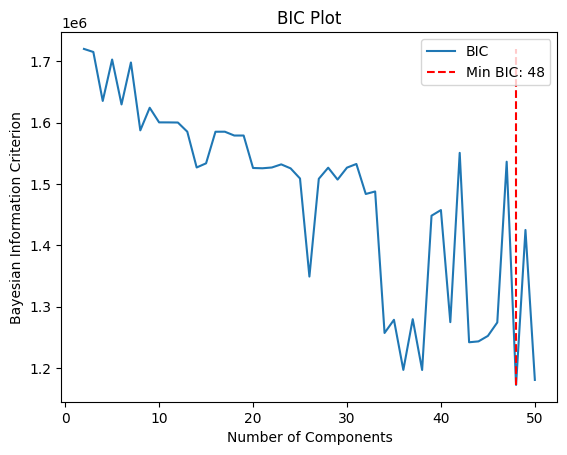

In [8]:
from sklearn.mixture import GaussianMixture
import numpy as np

X = all_meteorites[["mass (g)", "year", "reclong", "reclat"]]
y = all_meteorites[["Class Number"]]

bic = []
min_iter = 2
max_iter = 50 + 1
n_steps = 1
for n_clusters in range(min_iter, max_iter, n_steps):
    gmm = GaussianMixture(n_components=n_clusters).fit(X)
    bic.append(gmm.bic(X))
plt.plot(range(min_iter, max_iter, n_steps), bic, label='BIC')
min_bic = np.argmin(bic) * n_steps + min_iter
print(f"Best number of components: {min_bic}")
plt.title('BIC Plot')
plt.xlabel('Number of Components')
plt.ylabel('Bayesian Information Criterion')
plt.vlines(np.argmin(bic) * n_steps + min_iter, min(bic), max(bic), ls='--', color='red', label = f'Min BIC: {min_bic}')
plt.legend()
plt.savefig("./bayesian-information-criterion.png", format='png')
plt.show()

# takes 4.5 mins to run

## Ternary Plot to visualize classification

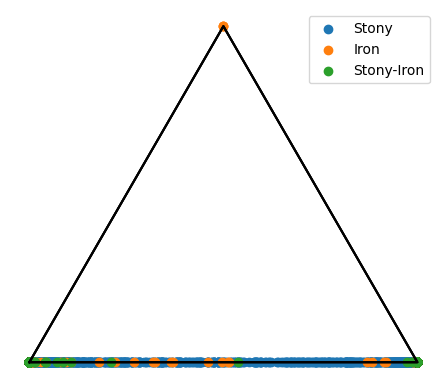

In [9]:

X = all_meteorites[["mass (g)", "year", "reclong", "reclat"]]
y = all_meteorites["Class Number"]

def ternary_plot(abc, label=None):
    """
    Make a ternary scatter plot.

    Note, if you call this function repeatedly, the scatter points will have
    different colors.

    Parameters
    ----------
    abc : numpy.ndarray of shape (n_samples, 3)
        Data to plot.
    label : str or None, optional
        Label to be used in a legend. Default is None.
    """
    a, b, c = abc.T
    x = 0.5 * (2 * b + c) / (a + b + c)
    y = np.sqrt(3) / 2 * c / (a + b + c)
    plt.plot([0, 1, 1 / 2, 0], [0, 0, np.sqrt(3) / 2, 0], color='black')
    plt.axis('off')
    plt.scatter(x, y, label=label)
    if label is not None:
        plt.legend(loc='best')
    plt.gca().set_aspect('equal')
    plt.savefig(f"ternary_plot.png", format='png')


stony = X[y == 1]
iron = X[y == 2]
stony_iron = X[y == 3]
gmm = GaussianMixture(n_components=3).fit(X)
stony_gauss = gmm.predict_proba(stony)
iron_gauss = gmm.predict_proba(iron)
stony_iron_gauss = gmm.predict_proba(stony_iron)
ternary_plot(stony_gauss, label='Stony')
ternary_plot(iron_gauss, label='Iron')
ternary_plot(stony_iron_gauss, label='Stony-Iron')


## Visualize location

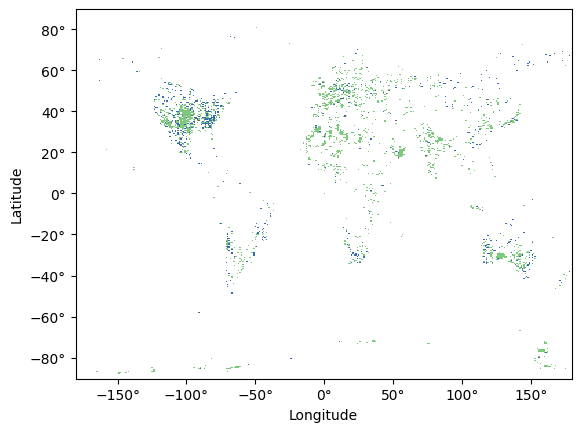

In [10]:
from matplotlib.ticker import StrMethodFormatter
from scipy.spatial import cKDTree


def show(lon, lat, c=None, n_pix=360):
    """Show the clusters on a map.

    The function will produce a plot of the globe where each pixel is colored
    according to the most common cluster label within each pixel.

    Parameters
    ----------
    lon : array_like
        Longitude.
    lat : array_like
        Latitude.
    c : array_like, optional
        Cluster label. If None, all points are assumed to have the same label.
        Default is None.
    n_pix : int
        How many pixels to use per longitude and latitude dimension. Default is
        360.
    """

    if c is None:
        c = np.zeros(len(lon), dtype=int)
    lon_grid = np.linspace(0, 360, n_pix, endpoint=False)
    lat_grid = np.linspace(0, 180, n_pix, endpoint=False)
    lon_grid, lat_grid = np.meshgrid(lon_grid, lat_grid)
    n_grid = len(lon_grid.ravel())
    tree = cKDTree(np.column_stack([lon_grid.ravel(), lat_grid.ravel()]),
                   boxsize=[360 + 1e-6, 1e99])

    idx = tree.query(np.column_stack([lon + 180, lat + 90]))[1]
    # Count occurrence per unique label.
    counts = np.zeros((n_grid, len(np.unique(c))))
    for i, c_i in enumerate(np.unique(c)):
        counts[:, i] = np.bincount(idx, weights=(c == c_i), minlength=n_grid)
    # Find the most common label in each grid point.
    c_grid = np.where(
        np.sum(counts, axis=1) > 0, np.argmax(counts, axis=1), np.nan)
    plt.pcolormesh(lon_grid - 180, lat_grid - 90,
                   c_grid.reshape(lat_grid.shape), cmap='Accent')
    plt.xlabel(r'Longitude')
    plt.ylabel(r'Latitude')
    plt.gca().xaxis.set_major_formatter(StrMethodFormatter(u"{x:.0f}°"))
    plt.gca().yaxis.set_major_formatter(StrMethodFormatter(u"{x:.0f}°"))
    plt.savefig(f"location-visualization.png", format='png')
    plt.show()


longitude = all_meteorites["reclong"]
latitude = all_meteorites["reclat"]
color = all_meteorites["Class Number"]
show(longitude, latitude, c=color)

## Finding Outliers

In [11]:
import csv

with open('./iron_gauss_file.csv', mode='w', newline='') as file:
    writer = csv.writer(file)
    writer.writerow(["Group 1", "Group 2", "Group 3"])
    writer.writerows(iron_gauss)

iron_df = pd.read_csv("iron_gauss_file.csv")
row_count = 0
suspect_list = []
for prob in iron_df["Group 3"]:
    if prob == 1.0:
        suspect_list.append(row_count)
    row_count += 1

iron_meteorites = X[y == 2]
for suspect in suspect_list:
    data_line = iron_meteorites.iloc[suspect, :]
    mass = data_line["mass (g)"]
    year = int(data_line["year"])
    longitude = data_line["reclong"]
    latitude = data_line["reclat"]

    for i, row in all_meteorites.iterrows():
        if row["mass (g)"] == mass and row["year"] == year and row["reclong"] == longitude and row["reclat"] == latitude:
            print(row["name"])


Campo del Cielo
Cape York
Hoba
